In [157]:
import pandas as pd
import numpy as np

In [158]:
df = pd.read_parquet(
    r"C:\Users\usuario\Desktop\data_ingestion\df_filtered.parquet"
)

In [159]:
df_artigo = df[[
    "cusip",
    "issuer_cusip",
    "date",
    "cs",
    "dcs6",
    "es_90",
    "cs_mu12_1",
    "spc_rat",
    "tmat",
    "md_dur",
    "convx",
    "age",
    "sze",
    "ami",
    "spd_rel",
    "roll",
    "b_dvix",
    "sig_dt",
    "ff30num",
    "mdc_rat",
    "ret_vw",
    "val_hz",
    "lix",
    "call",
    "dvol",
    "var_95"
]].rename(columns={
    "cusip": "bond_id",
    "issuer_cusip": "issuer_id",
    "date": "date",
    "cs": "credit_spread",
    "es_90": "expected_shortfall",
    "spc_rat": "sp_rating",
    "tmat": "maturity",
    "md_dur": "duration",
    "convx": "convexity",
    "age": "bond_age",
    "sze": "bond_size",
    "ami": "amihud_illiquidity",
    "spd_rel": "relative_spread",
    "roll": "roll_spread",
    "b_dvix": "vix_beta",
    "sig_dt": "signal_date",
    "ff30num": "industry_ff30",
    "mdc_rat": "mdc_rating",
    "ret_vw": "return",
    "dcs6": "var_spread_6m",
    "cs_mu12_1": "spread_movel_12m",
    "val_hz": "Desv_Pad_spread_justo",
    "lix": "liquid_lix",
    "dvol": "vol_diaria",
    "var_95": "var_95",
    "call": "call"
})

In [160]:
ff17_dict = {
    1: "Food",
    2: "Mining and Minerals",
    3: "Oil and Petroleum Products",
    4: "Textiles, Apparel & Footwear",
    5: "Consumer Durables",
    6: "Chemicals",
    7: "Drugs, Soap, Perfumes & Tobacco",
    8: "Construction & Construction Materials",
    9: "Steel Works",
    10: "Fabricated Products",
    11: "Machinery & Business Equipment",
    12: "Automobiles",
    13: "Transportation",
    14: "Utilities",
    15: "Retail Stores",
    16: "Financials",
    17: "Other"
}

In [161]:
titulos_por_data = (
    df.groupby("date")["cusip"]
      .nunique()
      .reset_index(name="n_titulos")
)

print(f"Média de títulos por mês: {titulos_por_data['n_titulos'].mean():,.0f}")
print(f"Mediana: {titulos_por_data['n_titulos'].median():,.0f}")
print(f"Mínimo: {titulos_por_data['n_titulos'].min():,.0f}")
print(f"Máximo: {titulos_por_data['n_titulos'].max():,.0f}")

Média de títulos por mês: 6,775
Mediana: 6,720
Mínimo: 4,279
Máximo: 9,555


In [162]:
print("="*80)
print("DATASET OVERVIEW")
print("="*80)

print(f"Observações: {len(df_artigo):,}")
print(f"Variáveis: {len(df_artigo.columns):,}")

print("\nTipos das variáveis:")
print(df_artigo.dtypes)

DATASET OVERVIEW
Observações: 1,239,851
Variáveis: 26

Tipos das variáveis:
bond_id                        category
issuer_id                      category
date                             object
credit_spread                   float32
var_spread_6m                   float32
expected_shortfall              float64
spread_movel_12m                float64
sp_rating                         int32
maturity                        float32
duration                        float32
convexity                       float32
bond_age                        float32
bond_size                       float32
amihud_illiquidity              float32
relative_spread                 float64
roll_spread                     float32
vix_beta                        float64
signal_date              datetime64[ns]
industry_ff30                      Int8
mdc_rating                        int32
return                          float32
Desv_Pad_spread_justo           float32
liquid_lix                      float32
call

Valores Nulos ou Vazios

In [163]:

print("\n")
print("="*80)
print("MISSING VALUES")
print("="*80)

missing = pd.DataFrame({
    "missing_count": df_artigo.isnull().sum(),
    "missing_pct": (
        df_artigo.isnull().sum()
        / len(df_artigo)
        * 100
    ).round(2)
})

missing = missing.sort_values(
    "missing_pct",
    ascending=False
)

print(missing)



MISSING VALUES
                       missing_count  missing_pct
vix_beta                      243809        19.66
expected_shortfall            219935        17.74
var_95                        219935        17.74
var_spread_6m                 184693        14.90
spread_movel_12m              179039        14.44
roll_spread                   172622        13.92
Desv_Pad_spread_justo         171555        13.84
liquid_lix                    146751        11.84
vol_diaria                    144794        11.68
amihud_illiquidity            144794        11.68
credit_spread                  60372         4.87
relative_spread                51067         4.12
bond_size                      32650         2.63
signal_date                    32626         2.63
convexity                      32650         2.63
duration                       32650         2.63
bond_id                            0         0.00
issuer_id                          0         0.00
maturity                         

In [164]:
df_model2 = df_artigo.dropna(
    subset=["vix_beta","roll_spread"]
).copy()

In [204]:
df_model = df_model2[
    [
        "bond_id",
        "issuer_id",
        "date",
        "credit_spread",          # variável dependente
        "amihud_illiquidity",
        "return",
        "vix_beta",
        "industry_ff30",
        "bond_age",
        "bond_size",
        "vol_diaria",
        "duration",
        "liquid_lix",
        "expected_shortfall",
        "var_95",
        "vol_diaria",
        "call",
        "roll_spread",
        "convexity"
    ]
].copy()

In [205]:

print("\n")
print("="*80)
print("MISSING VALUES")
print("="*80)

missing = pd.DataFrame({
    "missing_count": df_model.isnull().sum(),
    "missing_pct": (
        df_model.isnull().sum()
        / len(df_model)
        * 100
    ).round(2)
})

missing = missing.sort_values(
    "missing_pct",
    ascending=False
)

print(missing)



MISSING VALUES
                    missing_count  missing_pct
convexity                    2209         0.26
bond_size                    2209         0.26
credit_spread                2209         0.26
duration                     2209         0.26
liquid_lix                   1094         0.13
bond_id                         0         0.00
issuer_id                       0         0.00
date                            0         0.00
vix_beta                        0         0.00
return                          0         0.00
amihud_illiquidity              0         0.00
vol_diaria                      0         0.00
bond_age                        0         0.00
industry_ff30                   0         0.00
expected_shortfall              0         0.00
var_95                          0         0.00
vol_diaria                      0         0.00
call                            0         0.00
roll_spread                     0         0.00


In [206]:
print(f"Obs originais: {len(df_artigo):,}")
print(f"Obs finais:    {len(df_model):,}")

print(
    f"Perda (%): "
    f"{100*(1-len(df_model)/len(df_artigo)):.2f}"
)

Obs originais: 1,239,851
Obs finais:    862,514
Perda (%): 30.43


In [207]:
print("Amostra Final")

print(
    "Títulos:",
    df_model["bond_id"].nunique()
)

print(
    "Emissores:",
    df_model["issuer_id"].nunique()
)

print(
    "Observações:",
    len(df_model)
)

print(
    "Período:",
    df_model["date"].min(),
    "até",
    df_model["date"].max()
)

Amostra Final
Títulos: 23207
Emissores: 3879
Observações: 862514
Período: 2010-01-31 até 2024-12-31


Estatistica descritiva

In [208]:

print("\n")
print("="*80)
print("DESCRIPTIVE STATISTICS")
print("="*80)

numeric_cols = (
    df_model
    .select_dtypes(
        include=np.number
    )
    .columns
)

desc = (
    df_model[numeric_cols]
    .describe(
        percentiles=[
            .01,.05,.25,.50,.75,.95,.99
        ]
    )
    .T
)

print(desc)



DESCRIPTIVE STATISTICS
                       count        mean         std        min         1%  \
credit_spread       860305.0    0.021993    0.034586  -0.000709   0.001648   
amihud_illiquidity  862514.0     0.27771   15.260417   0.000019   0.000414   
return              862514.0    0.003687    0.037989  -0.969928   -0.08677   
vix_beta            862514.0   -0.009013    1.183235 -73.583364  -3.209733   
industry_ff30       862514.0   21.287628    8.075666        1.0        1.0   
bond_age            862514.0     5.58516    4.844692   0.960986   1.054072   
bond_size           860305.0  756.972412  709.165771   0.214073  12.924713   
vol_diaria          862514.0    0.007956    0.010206   0.000115    0.00074   
vol_diaria          862514.0    0.007956    0.010206   0.000115    0.00074   
duration            860305.0    6.443589    4.441317      0.002      1.036   
liquid_lix          861420.0   -2.026438    0.708373  -5.660741  -3.501973   
expected_shortfall  862514.0    0.04382

Variáveis do Modelo

In [209]:
df_model = df_model.loc[:, ~df_model.columns.duplicated()]

In [210]:
print("\n")
print("="*80)
print("OUTLIER CHECK")
print("="*80)

outlier_report = []

numeric_cols = df_model.select_dtypes(
    include=["number"]
).columns

for col in numeric_cols:

    q1 = df_model[col].quantile(.25)
    q3 = df_model[col].quantile(.75)

    iqr = q3 - q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    outliers = (
        (df_model[col] < lower)
        |
        (df_model[col] > upper)
    ).sum()

    outlier_report.append([
        col,
        outliers,
        round(
            outliers
            /
            len(df_model)
            *100,
            2
        )
    ])

outlier_report = pd.DataFrame(
    outlier_report,
    columns=[
        "variable",
        "outliers",
        "pct_outliers"
    ]
)

print(
    outlier_report.sort_values(
        "pct_outliers",
        ascending=False
    )
)




OUTLIER CHECK
              variable  outliers  pct_outliers
12                call    128083         14.85
14           convexity    119344         13.84
1   amihud_illiquidity    102293         11.86
2               return    102122         11.84
3             vix_beta     97183         11.27
0        credit_spread     73276          8.50
5             bond_age     60603          7.03
6            bond_size     60498          7.01
13         roll_spread     56498          6.55
7           vol_diaria     46314          5.37
11              var_95     45215          5.24
10  expected_shortfall     41717          4.84
4        industry_ff30     38511          4.46
8             duration     12755          1.48
9           liquid_lix      4576          0.53


DISTRIBUIÇÃO: duration
count    860305.000000
mean          6.443589
std           4.441317
min           0.002000
25%           3.101000
50%           5.077000
75%           8.719000
max          31.981001
Name: duration, dtype: float64

Assimetria: 0.9861
Curtose: 0.0156

Jarque-Bera:
Estatística: 139434.61
P-valor: 0.0


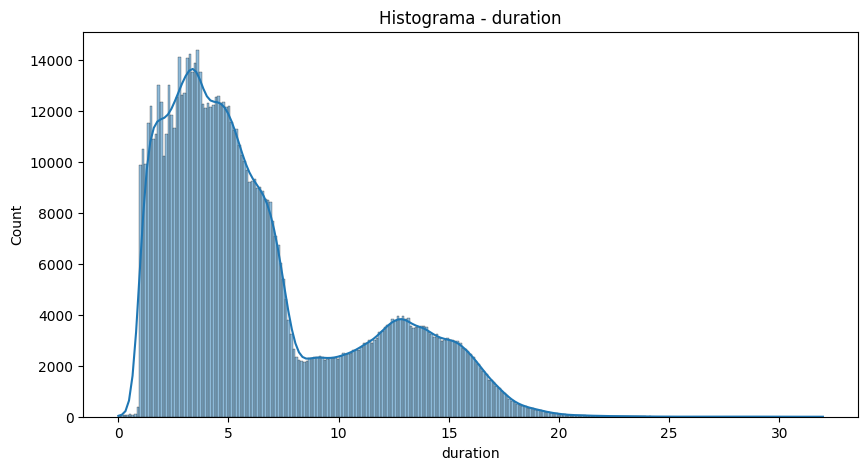

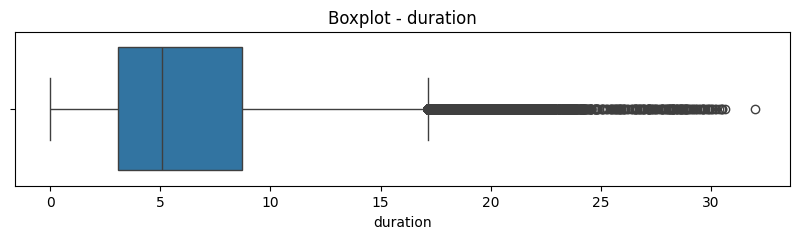

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, jarque_bera

col = "duration"  # altere a variável aqui

# Estatísticas descritivas
print("="*80)
print(f"DISTRIBUIÇÃO: {col}")
print("="*80)

print(df_model[col].describe())

print("\nAssimetria:", round(skew(df_model[col].dropna()), 4))
print("Curtose:", round(kurtosis(df_model[col].dropna()), 4))

jb_stat, jb_p = jarque_bera(df_model[col].dropna())

print("\nJarque-Bera:")
print("Estatística:", round(jb_stat, 4))
print("P-valor:", round(jb_p, 4))

# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df_model[col], kde=True)
plt.title(f"Histograma - {col}")
plt.show()

# Boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df_model[col])
plt.title(f"Boxplot - {col}")
plt.show()

In [212]:
df_model[col] = df_model[col].clip(
    lower=df_model[col].quantile(0.01),
    upper=df_model[col].quantile(0.99)
)

DISTRIBUIÇÃO: vol_diaria
count    862514.000000
mean          0.007956
std           0.010206
min           0.000115
25%           0.003042
50%           0.005637
75%           0.009899
max           1.470771
Name: vol_diaria, dtype: float64

Assimetria: 16.5916
Curtose: 944.1645

Jarque-Bera:
Estatística: 32076452787.4558
P-valor: 0.0


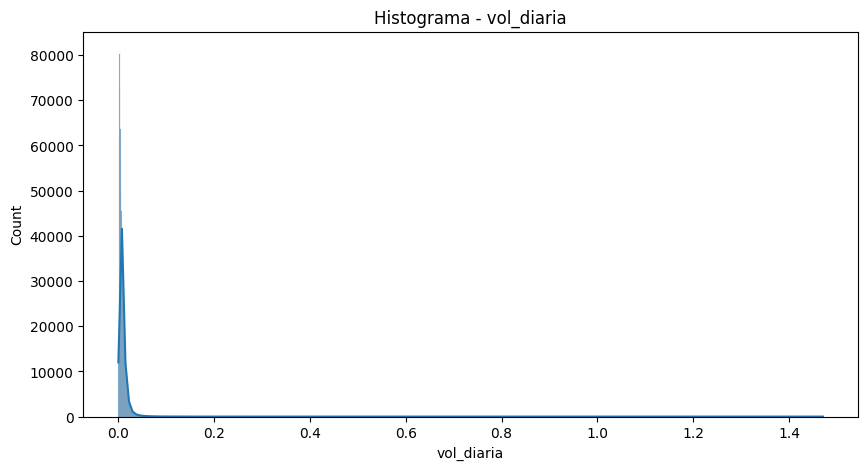

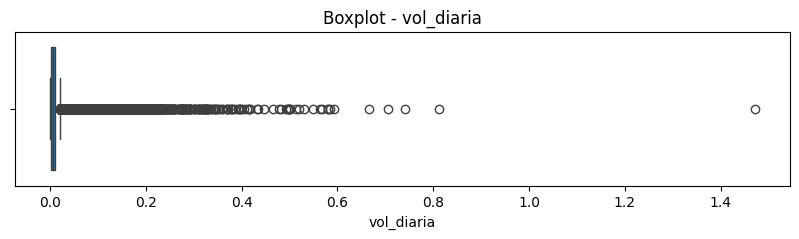

In [213]:

col = "vol_diaria"  # altere a variável aqui

# Estatísticas descritivas
print("="*80)
print(f"DISTRIBUIÇÃO: {col}")
print("="*80)

print(df_model[col].describe())

print("\nAssimetria:", round(skew(df_model[col].dropna()), 4))
print("Curtose:", round(kurtosis(df_model[col].dropna()), 4))

jb_stat, jb_p = jarque_bera(df_model[col].dropna())

print("\nJarque-Bera:")
print("Estatística:", round(jb_stat, 4))
print("P-valor:", round(jb_p, 4))

# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df_model[col], kde=True)
plt.title(f"Histograma - {col}")
plt.show()

# Boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df_model[col])
plt.title(f"Boxplot - {col}")
plt.show()

In [214]:
df_model[col] = df_model[col].clip(
    lower=df_model[col].quantile(0.01),
    upper=df_model[col].quantile(0.99)
)

DISTRIBUIÇÃO: roll_spread
count    862514.000000
mean          0.798439
std           1.594160
min           0.000000
25%           0.157563
50%           0.457156
75%           1.020602
max         302.526520
Name: roll_spread, dtype: float64

Assimetria: 41.0425
Curtose: 4149.3105

Jarque-Bera:
Estatística: 6.189801e+11
P-valor: 0.0


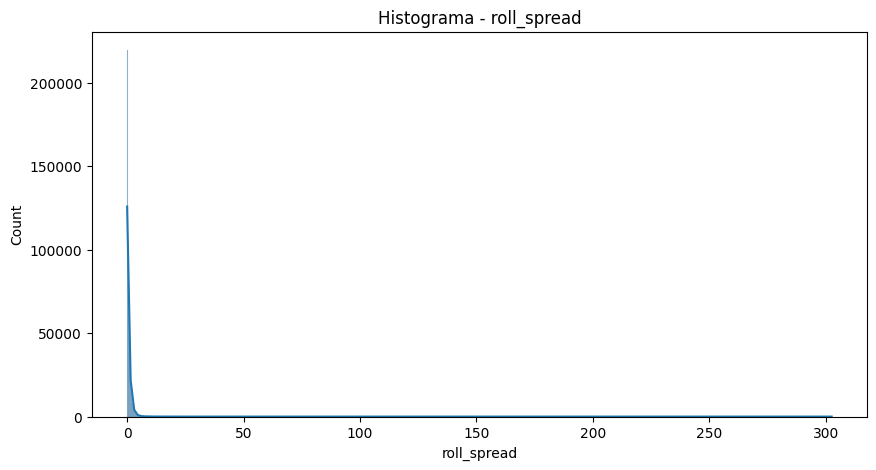

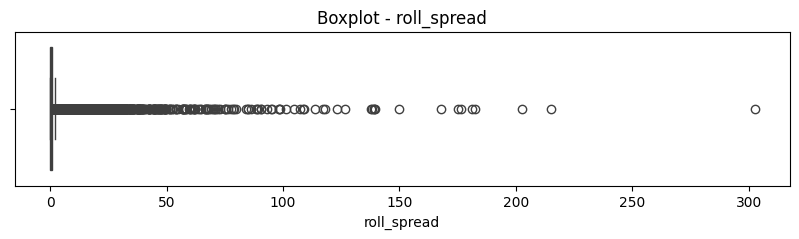

In [215]:

col = "roll_spread"  # altere a variável aqui

# Estatísticas descritivas
print("="*80)
print(f"DISTRIBUIÇÃO: {col}")
print("="*80)

print(df_model[col].describe())

print("\nAssimetria:", round(skew(df_model[col].dropna()), 4))
print("Curtose:", round(kurtosis(df_model[col].dropna()), 4))

jb_stat, jb_p = jarque_bera(df_model[col].dropna())

print("\nJarque-Bera:")
print("Estatística:", round(jb_stat, 4))
print("P-valor:", round(jb_p, 4))

# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df_model[col], kde=True)
plt.title(f"Histograma - {col}")
plt.show()

# Boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df_model[col])
plt.title(f"Boxplot - {col}")
plt.show()

In [216]:
df_model[col] = df_model[col].clip(
    lower=df_model[col].quantile(0.01),
    upper=df_model[col].quantile(0.99)
)

DISTRIBUIÇÃO: convexity
count    860305.000000
mean         82.675812
std         113.780815
min           0.000000
25%          11.670000
50%          30.791000
75%          98.823997
max        1763.532959
Name: convexity, dtype: float64

Assimetria: 2.0725
Curtose: 6.276

Jarque-Bera:
Estatística: 2.0278001e+06
P-valor: 0.0


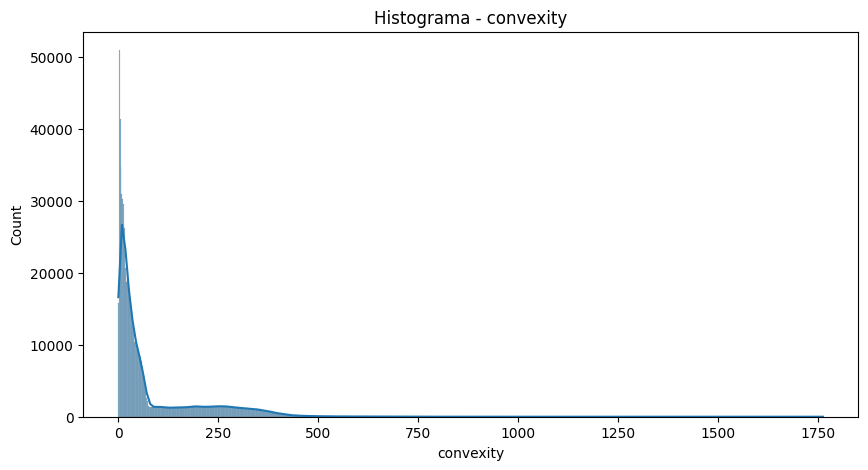

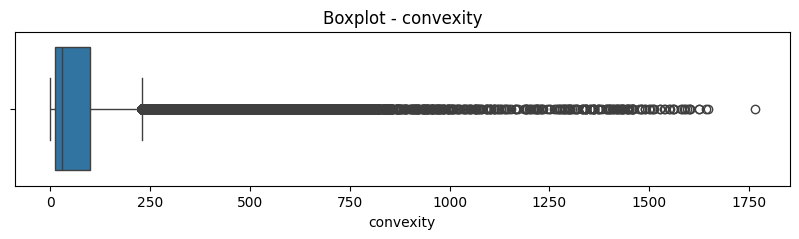

In [217]:

col = "convexity"  # altere a variável aqui

# Estatísticas descritivas
print("="*80)
print(f"DISTRIBUIÇÃO: {col}")
print("="*80)

print(df_model[col].describe())

print("\nAssimetria:", round(skew(df_model[col].dropna()), 4))
print("Curtose:", round(kurtosis(df_model[col].dropna()), 4))

jb_stat, jb_p = jarque_bera(df_model[col].dropna())

print("\nJarque-Bera:")
print("Estatística:", round(jb_stat, 4))
print("P-valor:", round(jb_p, 4))

# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df_model[col], kde=True)
plt.title(f"Histograma - {col}")
plt.show()

# Boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df_model[col])
plt.title(f"Boxplot - {col}")
plt.show()

In [218]:
df_model[col] = df_model[col].clip(
    lower=df_model[col].quantile(0.01),
    upper=df_model[col].quantile(0.99)
)

DISTRIBUIÇÃO: call
count    862514.000000
mean          0.851500
std           0.355595
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: call, dtype: float64

Assimetria: -1.977
Curtose: 1.9084

Jarque-Bera:
Estatística: 692733.8551
P-valor: 0.0


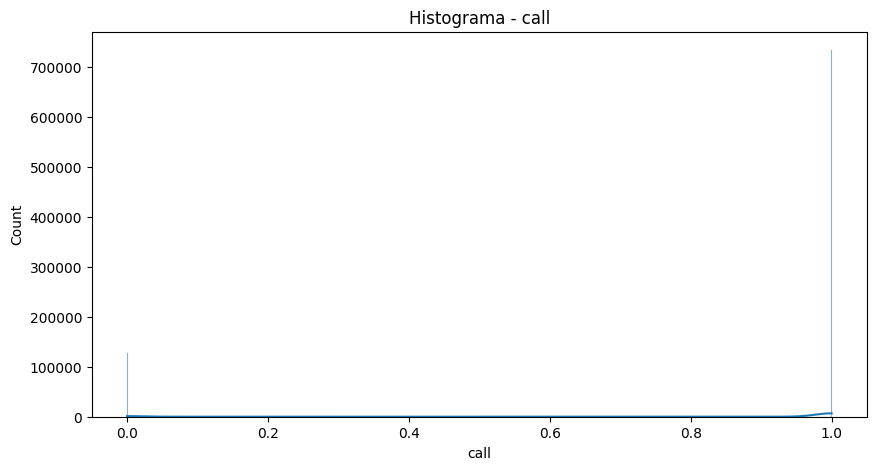

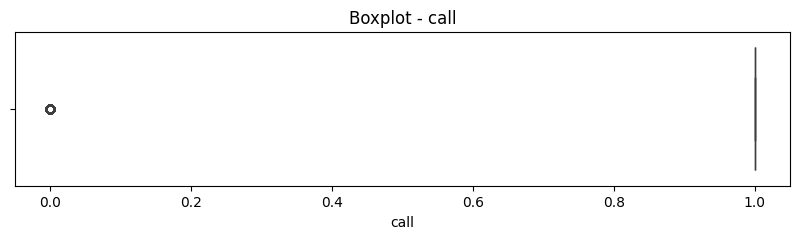

In [219]:

col = "call"  # altere a variável aqui

# Estatísticas descritivas
print("="*80)
print(f"DISTRIBUIÇÃO: {col}")
print("="*80)

print(df_model[col].describe())

print("\nAssimetria:", round(skew(df_model[col].dropna()), 4))
print("Curtose:", round(kurtosis(df_model[col].dropna()), 4))

jb_stat, jb_p = jarque_bera(df_model[col].dropna())

print("\nJarque-Bera:")
print("Estatística:", round(jb_stat, 4))
print("P-valor:", round(jb_p, 4))

# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df_model[col], kde=True)
plt.title(f"Histograma - {col}")
plt.show()

# Boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df_model[col])
plt.title(f"Boxplot - {col}")
plt.show()

In [220]:
df_model[col] = df_model[col].clip(
    lower=df_model[col].quantile(0.01),
    upper=df_model[col].quantile(0.99)
)

DISTRIBUIÇÃO: amihud_illiquidity
count    862514.000000
mean          0.277710
std          15.260417
min           0.000019
25%           0.009173
50%           0.038814
75%           0.140908
max        7602.304199
Name: amihud_illiquidity, dtype: float64

Assimetria: 288.8176
Curtose: 107084.97

Jarque-Bera:
Estatística: 4.1212084e+14
P-valor: 0.0


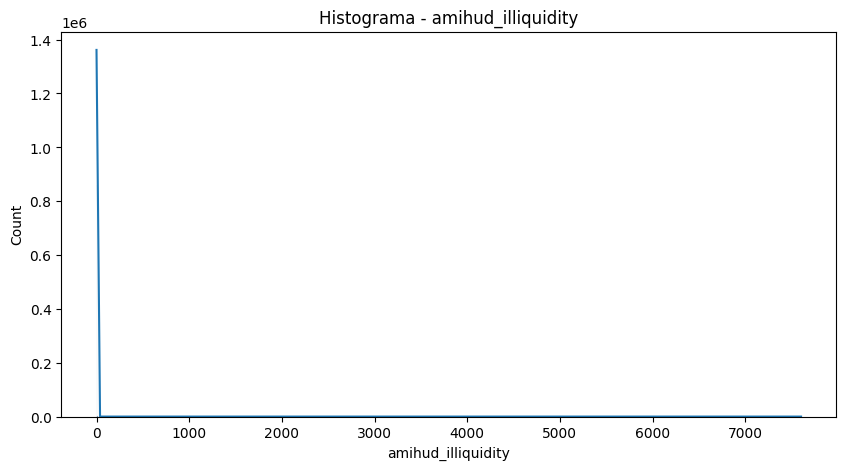

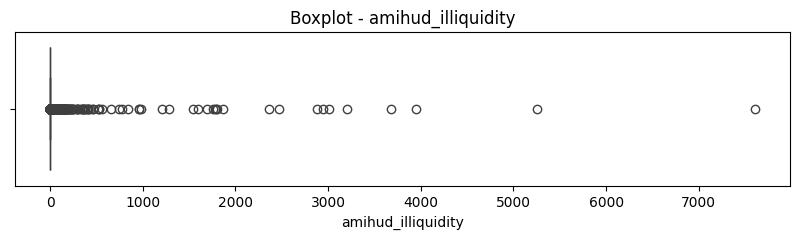

In [221]:

col = "amihud_illiquidity"  # altere a variável aqui

# Estatísticas descritivas
print("="*80)
print(f"DISTRIBUIÇÃO: {col}")
print("="*80)

print(df_model[col].describe())

print("\nAssimetria:", round(skew(df_model[col].dropna()), 4))
print("Curtose:", round(kurtosis(df_model[col].dropna()), 4))

jb_stat, jb_p = jarque_bera(df_model[col].dropna())

print("\nJarque-Bera:")
print("Estatística:", round(jb_stat, 4))
print("P-valor:", round(jb_p, 4))

# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df_model[col], kde=True)
plt.title(f"Histograma - {col}")
plt.show()

# Boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df_model[col])
plt.title(f"Boxplot - {col}")
plt.show()

In [222]:
df_model[col] = df_model[col].clip(
    lower=df_model[col].quantile(0.01),
    upper=df_model[col].quantile(0.99)
)

DISTRIBUIÇÃO: return
count    862514.000000
mean          0.003687
std           0.037989
min          -0.969928
25%          -0.005706
50%           0.003179
75%           0.013817
max           5.393131
Name: return, dtype: float64

Assimetria: 8.3771
Curtose: 1000.6496

Jarque-Bera:
Estatística: 3.5994874e+10
P-valor: 0.0


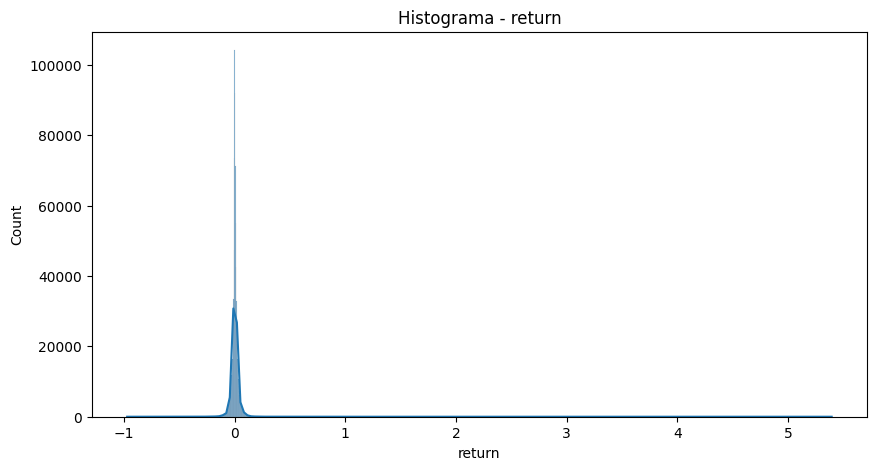

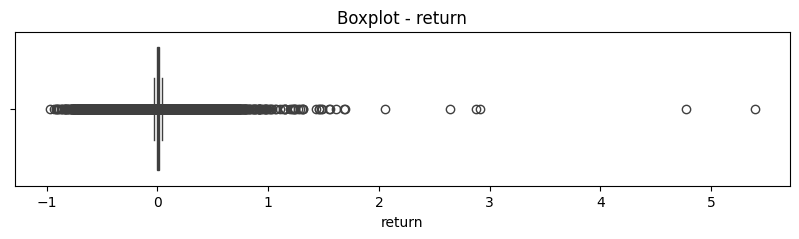

In [223]:

col = "return"  # altere a variável aqui

# Estatísticas descritivas
print("="*80)
print(f"DISTRIBUIÇÃO: {col}")
print("="*80)

print(df_model[col].describe())

print("\nAssimetria:", round(skew(df_model[col].dropna()), 4))
print("Curtose:", round(kurtosis(df_model[col].dropna()), 4))

jb_stat, jb_p = jarque_bera(df_model[col].dropna())

print("\nJarque-Bera:")
print("Estatística:", round(jb_stat, 4))
print("P-valor:", round(jb_p, 4))

# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df_model[col], kde=True)
plt.title(f"Histograma - {col}")
plt.show()

# Boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df_model[col])
plt.title(f"Boxplot - {col}")
plt.show()

In [224]:
df_model[col] = df_model[col].clip(
    lower=df_model[col].quantile(0.01),
    upper=df_model[col].quantile(0.99)
)

DISTRIBUIÇÃO: vix_beta
count    862514.000000
mean         -0.009013
std           1.183235
min         -73.583364
25%          -0.299030
50%           0.006111
75%           0.298563
max          50.818657
Name: vix_beta, dtype: float64

Assimetria: -2.3187
Curtose: 188.1045

Jarque-Bera:
Estatística: 1272380915.6617
P-valor: 0.0


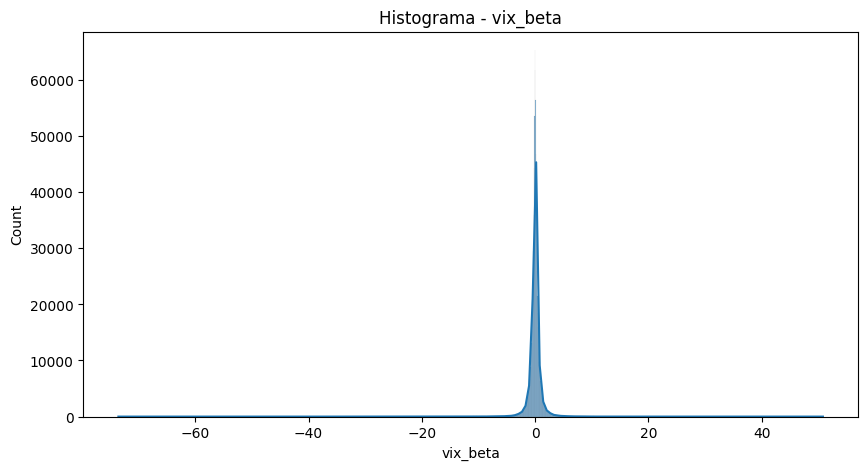

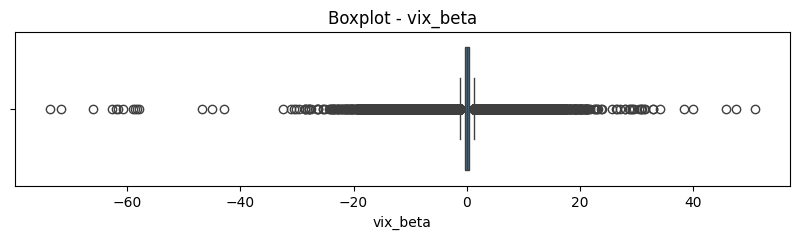

In [225]:
col = "vix_beta"  # altere a variável aqui

# Estatísticas descritivas
print("="*80)
print(f"DISTRIBUIÇÃO: {col}")
print("="*80)

print(df_model[col].describe())

print("\nAssimetria:", round(skew(df_model[col].dropna()), 4))
print("Curtose:", round(kurtosis(df_model[col].dropna()), 4))

jb_stat, jb_p = jarque_bera(df_model[col].dropna())

print("\nJarque-Bera:")
print("Estatística:", round(jb_stat, 4))
print("P-valor:", round(jb_p, 4))

# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df_model[col], kde=True)
plt.title(f"Histograma - {col}")
plt.show()

# Boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df_model[col])
plt.title(f"Boxplot - {col}")
plt.show()

In [226]:
df_model[col] = df_model[col].clip(
    lower=df_model[col].quantile(0.01),
    upper=df_model[col].quantile(0.99)
)

credit_spread

DISTRIBUIÇÃO: credit_spread
count    860305.000000
mean          0.021993
std           0.034586
min          -0.000709
25%           0.008193
50%           0.013492
75%           0.024403
max           1.369655
Name: credit_spread, dtype: float64

Assimetria: 11.6871
Curtose: 243.7506

Jarque-Bera:
Estatística: 2.1493535e+09
P-valor: 0.0


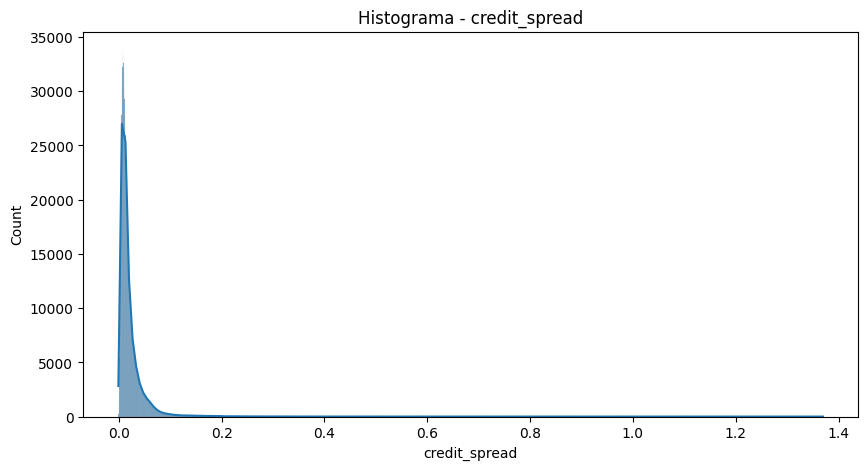

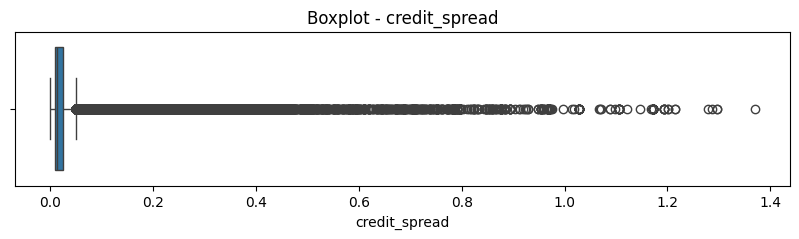

In [227]:
col = "credit_spread"  # altere a variável aqui

# Estatísticas descritivas
print("="*80)
print(f"DISTRIBUIÇÃO: {col}")
print("="*80)

print(df_model[col].describe())

print("\nAssimetria:", round(skew(df_model[col].dropna()), 4))
print("Curtose:", round(kurtosis(df_model[col].dropna()), 4))

jb_stat, jb_p = jarque_bera(df_model[col].dropna())

print("\nJarque-Bera:")
print("Estatística:", round(jb_stat, 4))
print("P-valor:", round(jb_p, 4))

# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df_model[col], kde=True)
plt.title(f"Histograma - {col}")
plt.show()

# Boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df_model[col])
plt.title(f"Boxplot - {col}")
plt.show()

In [228]:
df_model[col] = df_model[col].clip(
    lower=df_model[col].quantile(0.01),
    upper=df_model[col].quantile(0.99)
)

DISTRIBUIÇÃO: bond_age
count    862514.000000
mean          5.585160
std           4.844692
min           0.960986
25%           2.422998
50%           4.079398
75%           7.014374
max          89.163589
Name: bond_age, dtype: float64

Assimetria: 2.3863
Curtose: 9.2516

Jarque-Bera:
Estatística: 3.8945978e+06
P-valor: 0.0


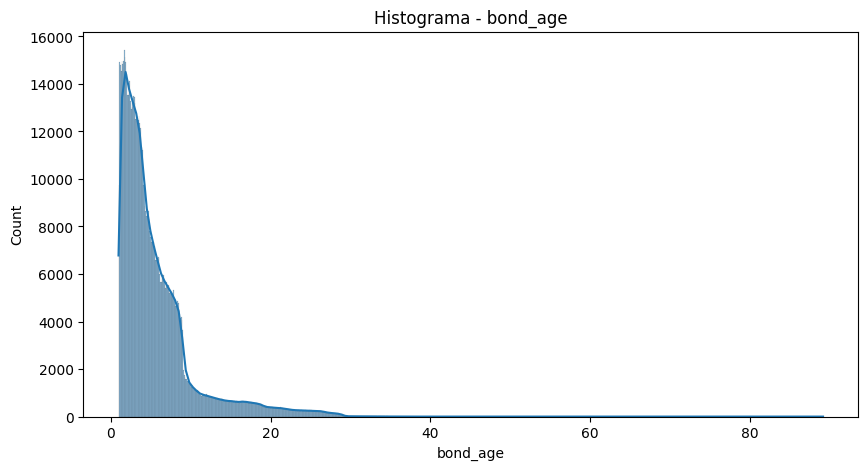

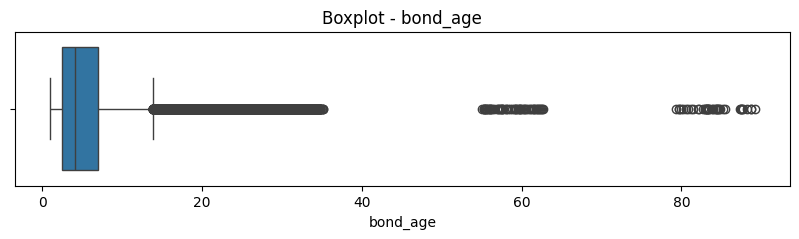

In [229]:
col = "bond_age"  # altere a variável aqui

# Estatísticas descritivas
print("="*80)
print(f"DISTRIBUIÇÃO: {col}")
print("="*80)

print(df_model[col].describe())

print("\nAssimetria:", round(skew(df_model[col].dropna()), 4))
print("Curtose:", round(kurtosis(df_model[col].dropna()), 4))

jb_stat, jb_p = jarque_bera(df_model[col].dropna())

print("\nJarque-Bera:")
print("Estatística:", round(jb_stat, 4))
print("P-valor:", round(jb_p, 4))

# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df_model[col], kde=True)
plt.title(f"Histograma - {col}")
plt.show()

# Boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df_model[col])
plt.title(f"Boxplot - {col}")
plt.show()

In [230]:
df_model[col] = df_model[col].clip(
    lower=df_model[col].quantile(0.01),
    upper=df_model[col].quantile(0.99)
)

DISTRIBUIÇÃO: bond_size
count    860305.000000
mean        756.972412
std         709.165771
min           0.214073
25%         354.960968
50%         554.476685
75%         935.626221
max       14502.484375
Name: bond_size, dtype: float64

Assimetria: 3.4028
Curtose: 24.4884

Jarque-Bera:
Estatística: 2.315647e+07
P-valor: 0.0


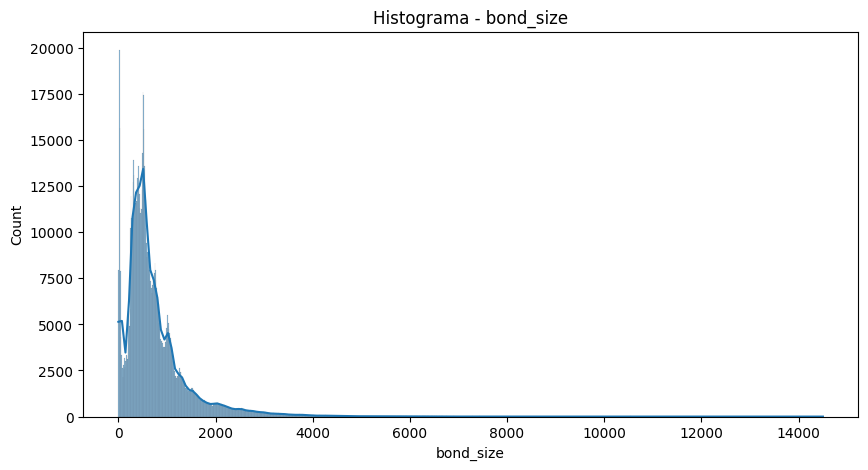

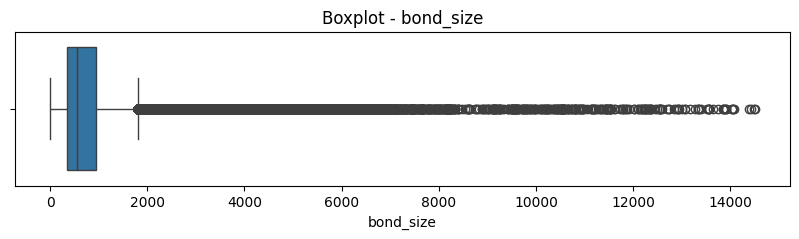

In [231]:
col = "bond_size"  # altere a variável aqui

# Estatísticas descritivas
print("="*80)
print(f"DISTRIBUIÇÃO: {col}")
print("="*80)

print(df_model[col].describe())

print("\nAssimetria:", round(skew(df_model[col].dropna()), 4))
print("Curtose:", round(kurtosis(df_model[col].dropna()), 4))

jb_stat, jb_p = jarque_bera(df_model[col].dropna())

print("\nJarque-Bera:")
print("Estatística:", round(jb_stat, 4))
print("P-valor:", round(jb_p, 4))

# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df_model[col], kde=True)
plt.title(f"Histograma - {col}")
plt.show()

# Boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df_model[col])
plt.title(f"Boxplot - {col}")
plt.show()

In [232]:
df_model[col] = df_model[col].clip(
    lower=df_model[col].quantile(0.01),
    upper=df_model[col].quantile(0.99)
)

DISTRIBUIÇÃO: expected_shortfall
count    862514.000000
mean          0.043827
std           0.043485
min          -0.006825
25%           0.018276
50%           0.032733
75%           0.054688
max           0.781614
Name: expected_shortfall, dtype: float64

Assimetria: 3.8597
Curtose: 23.8243

Jarque-Bera:
Estatística: 22539919.665
P-valor: 0.0


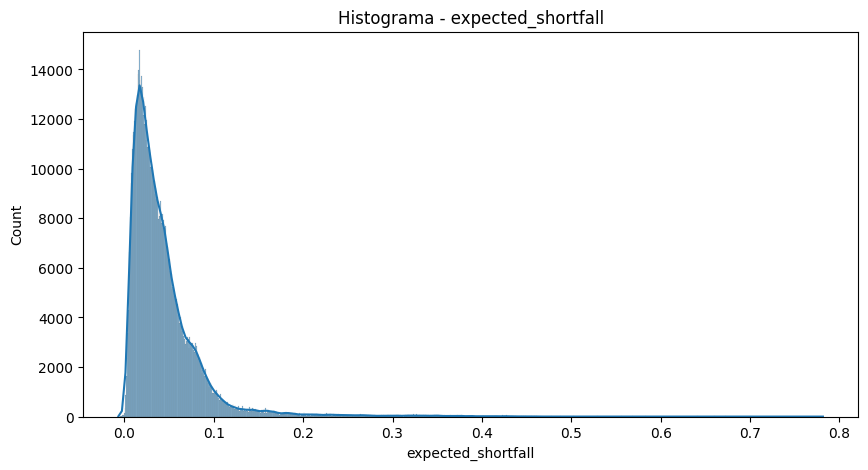

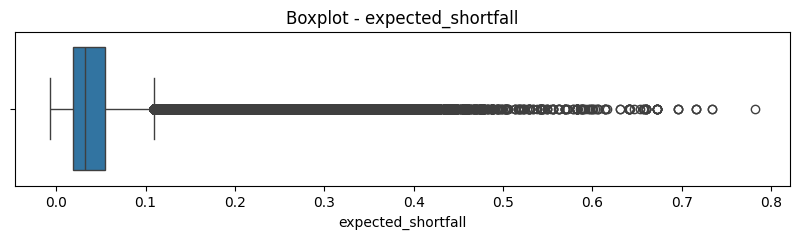

In [233]:
col = "expected_shortfall"  # altere a variável aqui

# Estatísticas descritivas
print("="*80)
print(f"DISTRIBUIÇÃO: {col}")
print("="*80)

print(df_model[col].describe())

print("\nAssimetria:", round(skew(df_model[col].dropna()), 4))
print("Curtose:", round(kurtosis(df_model[col].dropna()), 4))

jb_stat, jb_p = jarque_bera(df_model[col].dropna())

print("\nJarque-Bera:")
print("Estatística:", round(jb_stat, 4))
print("P-valor:", round(jb_p, 4))

# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df_model[col], kde=True)
plt.title(f"Histograma - {col}")
plt.show()

# Boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df_model[col])
plt.title(f"Boxplot - {col}")
plt.show()

In [234]:
df_model[col] = df_model[col].clip(
    lower=df_model[col].quantile(0.01),
    upper=df_model[col].quantile(0.99)
)

DISTRIBUIÇÃO: var_95
count    862514.000000
mean          0.044054
std           0.047040
min          -0.005138
25%           0.017642
50%           0.031940
75%           0.054118
max           0.887131
Name: var_95, dtype: float64

Assimetria: 4.447
Curtose: 31.785

Jarque-Bera:
Estatística: 39150544.6581
P-valor: 0.0


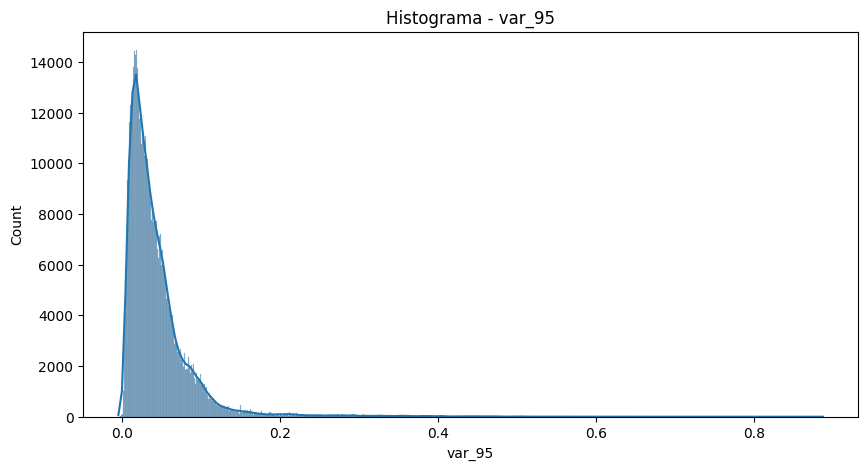

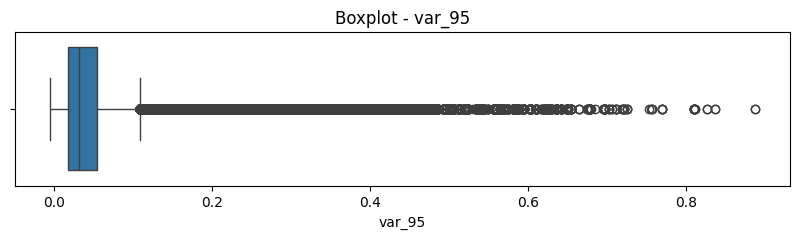

In [235]:
col = "var_95"  # altere a variável aqui

# Estatísticas descritivas
print("="*80)
print(f"DISTRIBUIÇÃO: {col}")
print("="*80)

print(df_model[col].describe())

print("\nAssimetria:", round(skew(df_model[col].dropna()), 4))
print("Curtose:", round(kurtosis(df_model[col].dropna()), 4))

jb_stat, jb_p = jarque_bera(df_model[col].dropna())

print("\nJarque-Bera:")
print("Estatística:", round(jb_stat, 4))
print("P-valor:", round(jb_p, 4))

# Histograma
plt.figure(figsize=(10,5))
sns.histplot(df_model[col], kde=True)
plt.title(f"Histograma - {col}")
plt.show()

# Boxplot
plt.figure(figsize=(10,2))
sns.boxplot(x=df_model[col])
plt.title(f"Boxplot - {col}")
plt.show()

In [236]:
df_model[col] = df_model[col].clip(
    lower=df_model[col].quantile(0.01),
    upper=df_model[col].quantile(0.99)
)

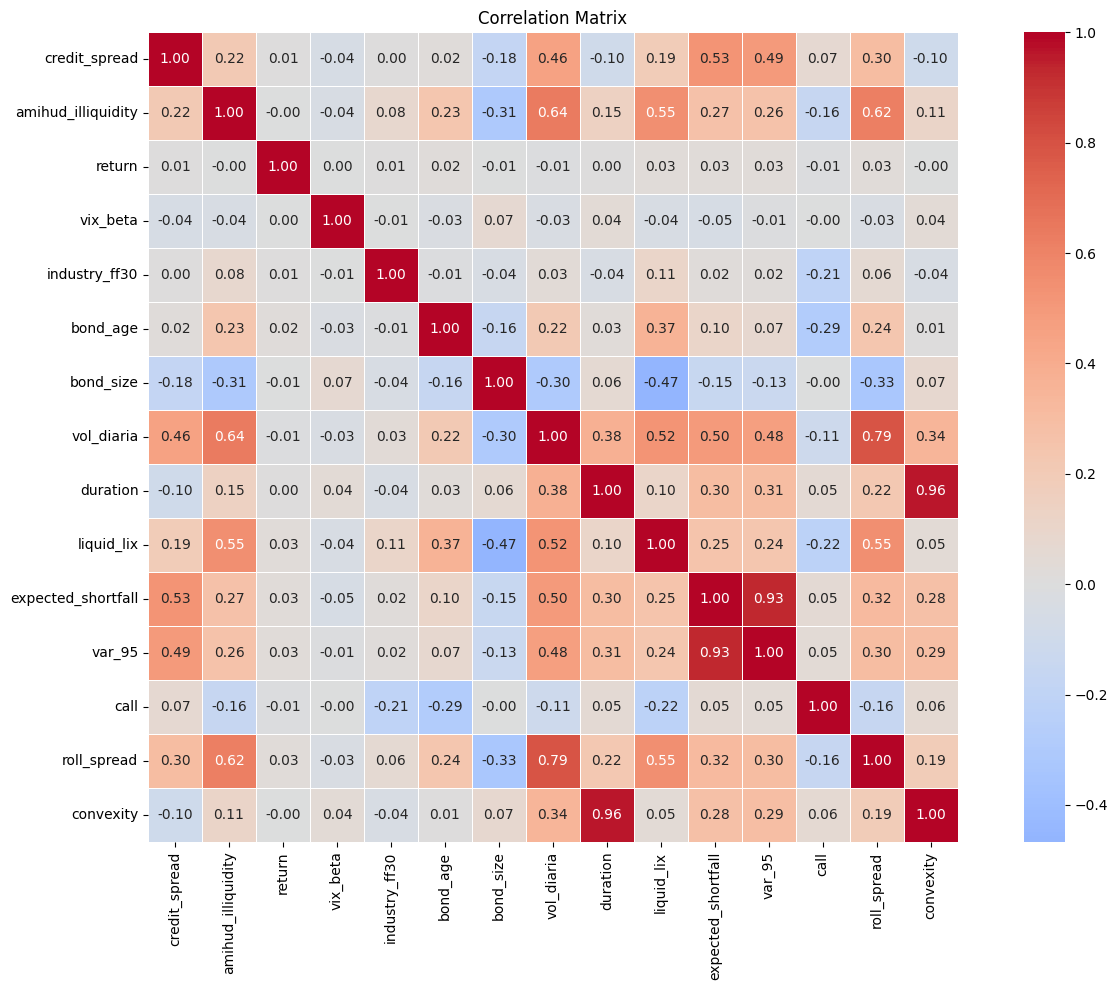

In [237]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df_model[numeric_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,      # mostra os valores
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Estatistica descritiva visual

In [238]:
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
credit_spread,860305.0,0.020871,0.022481,0.001648,0.008193,0.013492,0.024403,0.145226
amihud_illiquidity,862514.0,0.154585,0.322018,0.000414,0.009173,0.038814,0.140908,2.124805
return,862514.0,0.003747,0.026139,-0.08677,-0.005706,0.003179,0.013817,0.096363
vix_beta,862514.0,-0.004575,0.839081,-3.209733,-0.29903,0.006111,0.298563,3.129853
industry_ff30,862514.0,21.287628,8.075666,1.0,19.0,22.0,29.0,30.0
bond_age,862514.0,5.560431,4.710865,1.054072,2.422998,4.079398,7.014374,24.848734
bond_size,860305.0,746.051758,639.975403,12.924713,354.960968,554.476685,935.626221,3500.838623
vol_diaria,862514.0,0.007644,0.006803,0.00074,0.003042,0.005637,0.009899,0.03978
duration,860305.0,6.429859,4.397923,1.036,3.101,5.077,8.719,17.622
liquid_lix,861420.0,-2.026438,0.708373,-5.660741,-2.533056,-2.105131,-1.565094,3.090229


In [239]:
df_model.isna().sum()

bond_id                  0
issuer_id                0
date                     0
credit_spread         2209
amihud_illiquidity       0
return                   0
vix_beta                 0
industry_ff30            0
bond_age                 0
bond_size             2209
vol_diaria               0
duration              2209
liquid_lix            1094
expected_shortfall       0
var_95                   0
call                     0
roll_spread              0
convexity             2209
dtype: int64

In [240]:
missing = pd.DataFrame({
    "missing": df_model.isna().sum(),
    "pct_missing": (
        df_model.isna().mean() * 100
    ).round(2)
})

missing = missing.sort_values(
    "pct_missing",
    ascending=False
)

print(missing)

                    missing  pct_missing
bond_size              2209         0.26
credit_spread          2209         0.26
convexity              2209         0.26
duration               2209         0.26
liquid_lix             1094         0.13
bond_id                   0         0.00
issuer_id                 0         0.00
return                    0         0.00
amihud_illiquidity        0         0.00
date                      0         0.00
bond_age                  0         0.00
industry_ff30             0         0.00
vix_beta                  0         0.00
vol_diaria                0         0.00
expected_shortfall        0         0.00
var_95                    0         0.00
call                      0         0.00
roll_spread               0         0.00


In [244]:
df_model = df_model.rename(
    columns={"return": "bond_return"}
)

df_model = df_model.dropna(
    subset=vars_modelo
)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
!pip install linearmodels
from linearmodels.panel import PanelOLS




[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [245]:
df_panel = df_model.copy()

df_panel["date"] = pd.to_datetime(df_panel["date"])

df_panel = df_panel.set_index(
    ["bond_id", "date"]
)

In [ ]:
import statsmodels.formula.api as smf

m2 = smf.ols(
    "credit_spread ~ var_95 + call + roll_spread + bond_return + amihud_illiquidity + vix_beta + bond_age + bond_size + duration + liquid_lix",
    data=df_model
).fit()

print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:          credit_spread   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                 4.827e+04
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:42:59   Log-Likelihood:             2.2331e+06
No. Observations:              859265   AIC:                        -4.466e+06
Df Residuals:                  859254   BIC:                        -4.466e+06
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.0113      0

In [ ]:
y = df_panel["credit_spread"]

X = df_panel[
    [
        "expected_shortfall",
        "roll_spread",
        "bond_age",
        "bond_size",
        "duration",
        "vol_diaria",
        "convexity",
        "vix_beta"
    ]
]

y.isna().sum()
X.isna().sum()

expected_shortfall    0
roll_spread           0
bond_age              0
bond_size             0
duration              0
vol_diaria            0
convexity             0
vix_beta              0
es_lag                0
dtype: int64

In [258]:
fe_model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

fe_res = fe_model.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(fe_res.summary)

C:\Users\usuario\AppData\Local\Temp\ipykernel_14528\3553789563.py:8: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  fe_res = fe_model.fit(


                          PanelOLS Estimation Summary                           
Dep. Variable:          credit_spread   R-squared:                        0.2748
Estimator:                   PanelOLS   R-squared (Between):              0.0954
No. Observations:              836162   R-squared (Within):               0.2344
Date:                Sun, Jun 07 2026   R-squared (Overall):             -0.0708
Time:                        19:03:37   Log-likelihood                   2.9e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   3.427e+04
Entities:                       21979   P-value                           0.0000
Avg Obs:                       38.044   Distribution:                F(9,813996)
Min Obs:                       1.0000                                           
Max Obs:                       179.00   F-statistic (robust):             555.38
                            

In [259]:
df_panel[
    ["expected_shortfall", "es_lag"]
].corr()

,expected_shortfall,es_lag
expected_shortfall,1.000000,0.987834
es_lag,0.987834,1.000000


In [ ]:
from linearmodels.panel import RandomEffects

re_model = RandomEffects(
    y,
    X
)

re_res = re_model.fit()

print(re_res.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:          credit_spread   R-squared:                        0.1903
Estimator:              RandomEffects   R-squared (Between):              0.4134
No. Observations:              859265   R-squared (Within):               0.1718
Date:                Sun, Jun 07 2026   R-squared (Overall):              0.4332
Time:                        18:03:50   Log-likelihood                 2.798e+06
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                   2.524e+04
Entities:                       23162   P-value                           0.0000
Avg Obs:                       37.098   Distribution:                F(8,859257)
Min Obs:                       1.0000                                           
Max Obs:                       180.00   F-statistic (robust):          2.524e+04
                            

In [248]:
from scipy import stats
import numpy as np

b = fe_res.params
B = re_res.params

common_coef = b.index.intersection(B.index)

b = b[common_coef]
B = B[common_coef]

Vb = fe_res.cov.loc[common_coef, common_coef]
VB = re_res.cov.loc[common_coef, common_coef]

diff = b - B

stat = np.dot(
    np.dot(diff.T, np.linalg.inv(Vb - VB)),
    diff
)

df_h = len(diff)

pval = 1 - stats.chi2.cdf(stat, df_h)

print("Hausman Statistic:", stat)
print("p-value:", pval)

Hausman Statistic: 2203.364597591322
p-value: 0.0


In [ ]:
df_model.dtypes

bond_id                     category
issuer_id                   category
date                          object
credit_spread                float32
expected_shortfall           float64
sp_rating                      int32
maturity                     float32
duration                     float32
convexity                    float32
callable                        int8
bond_age                     float32
bond_size                    float32
amihud_illiquidity           float32
relative_spread              float64
roll_spread                  float32
vix_beta                     float64
signal_date           datetime64[ns]
signal_gap                   float64
industry_ff17                   Int8
mdc_rating                     int32
dtype: object